___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Проверочный проект по моделям машинного обучения с учителем (supervised learning) - Методы на основе деревьев



## Этот проверочный проект можно выполнять тремя разными способами - мы обсуждаем это в видео-лекции с обзором проверочных заданий!

----

**Проверочный проект можно выполнять одним из трёх способов:**
   1. Открыть новый блокнот Jupyter Notebook, загрузить данные из файла - и далее самостоятельно выполнить анализ и визуализацию данных, а также создать предиктивную модель.
   2. Использовать блокнот с заданиями как общее руководство к действию, выполняя задания, написанные жирным шрифтом.
   3. Сразу перейти к блокноту с решениями и видео-лекциям с решениями, и параллельно с просмотром лекций выполнять эти задания в своём блокноте.

------
------

## ЦЕЛЬ: Создать модель предсказания того, уйдёт ли абонент в отток (churn).

----
----


## Выполните задания ниже, обозначенные жирным шрифтом!

## Часть 0: Импортируем библиотеки и загружаем данные

**Задание: Запустите уже готовые ячейки ниже, чтобы импортировать библиотеки и загрузить данные из файла в датафрейм. Файл называется "Telco-Customer-Churn.csv"**

In [2]:
# Запустите эти ячейки для начала выполнения проекта!
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('../DATA/Telco-Customer-Churn.csv')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Часть 1: Общие характеристики данных

**Задание: С помощью метода .info() проверьте типы данных для колонок, а также есть ли отсутствующие значения в Вашем датафрейме.**

In [5]:
# Напишите Ваш код в этой ячейке
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 


**Задание: Выведите статистические метрики для числовых колонок с помощью .describe(). Вы увидите, что большинство колонок являются категориальными, поэтому Вам позднее нужно будет создать для них дамми-переменные.**

In [6]:
# Напишите Ваш код в этой ячейке


# Часть 2:  Исследование данных (Exploratory Data Analysis)

## Исследование признаков

**Задание: Проверьте, что в этих данных нет отсутствующих значений - для этого выведите количество значений NaN отдельно для каждой колонки.**

In [5]:
# Напишите Ваш код в этой ячейке
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Задание: Постройте график CountPlot для проверки сбалансированности значений колонки с классами (Churn).**

<Axes: xlabel='Churn', ylabel='count'>

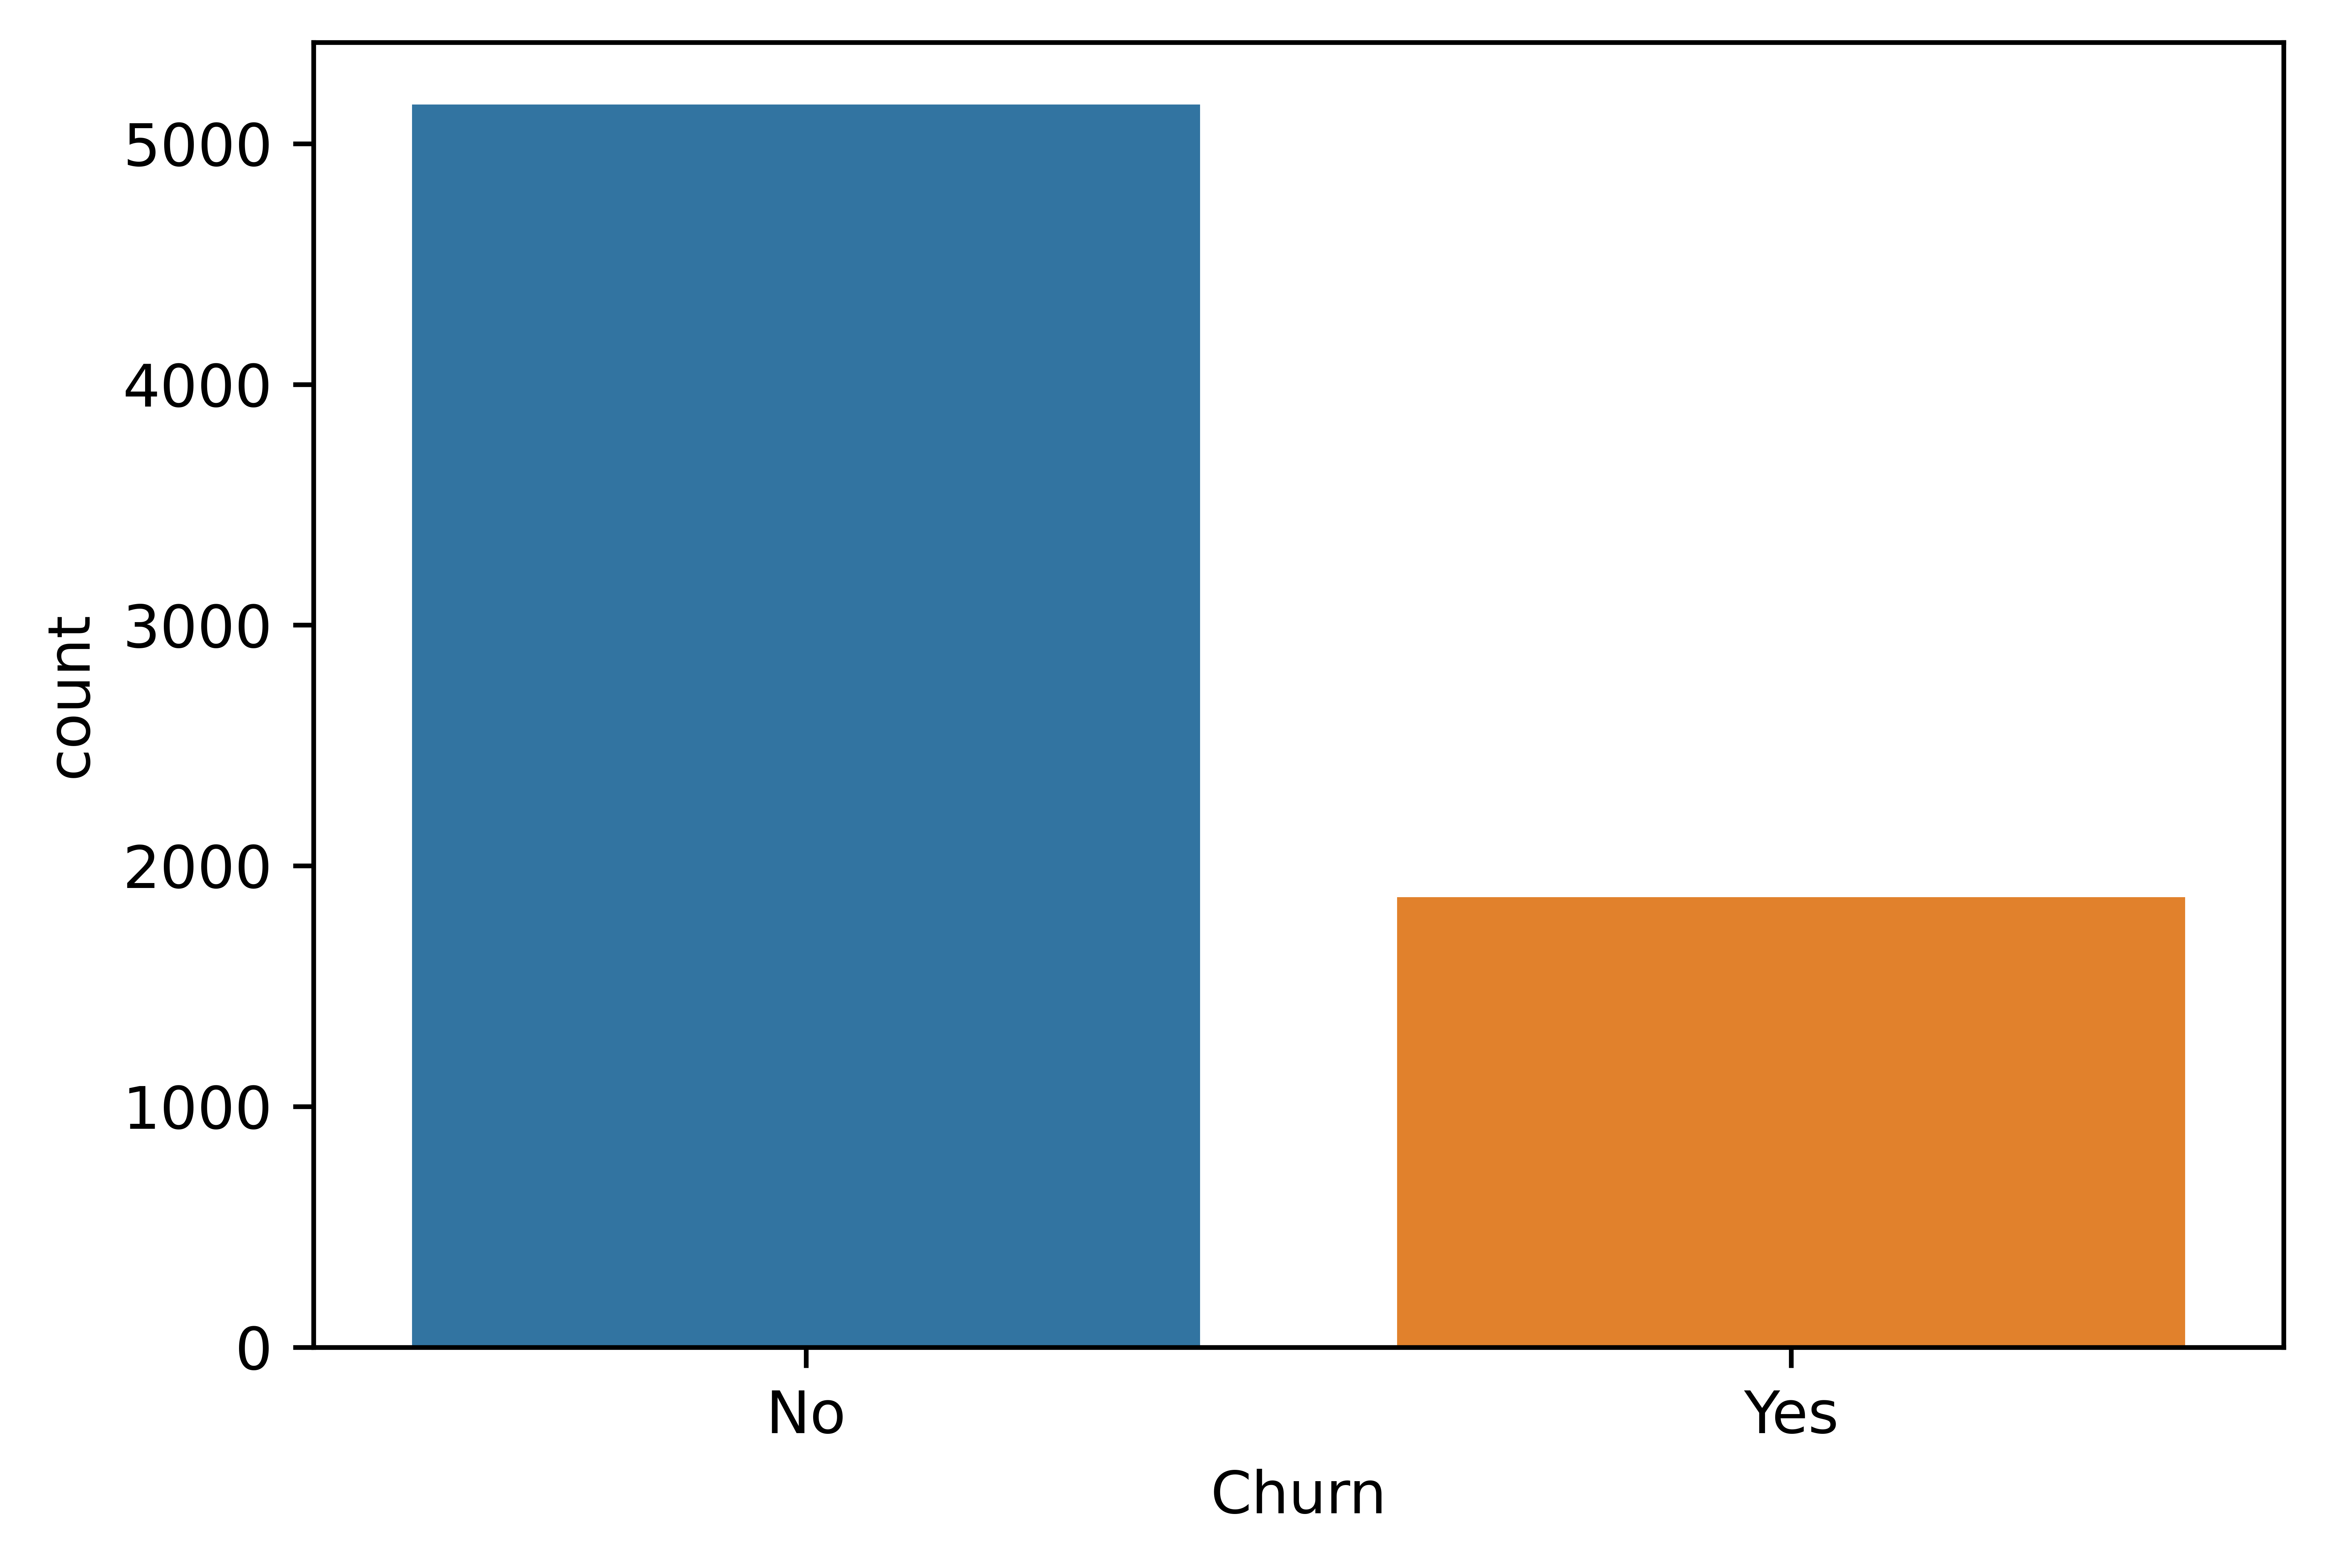

In [6]:
# Напишите Ваш код в этой ячейке
fig  = plt.figure(figsize = (6, 4), dpi= 1200)
sns.countplot(data = df, x = 'Churn', hue = 'Churn')

<img src='fig1.png' >

**Задание: Исследуйте распределение колонки TotalCharges по различным категориям Churn с помощью графика Box Plot или Violin Plot.**

<Axes: ylabel='TotalCharges'>

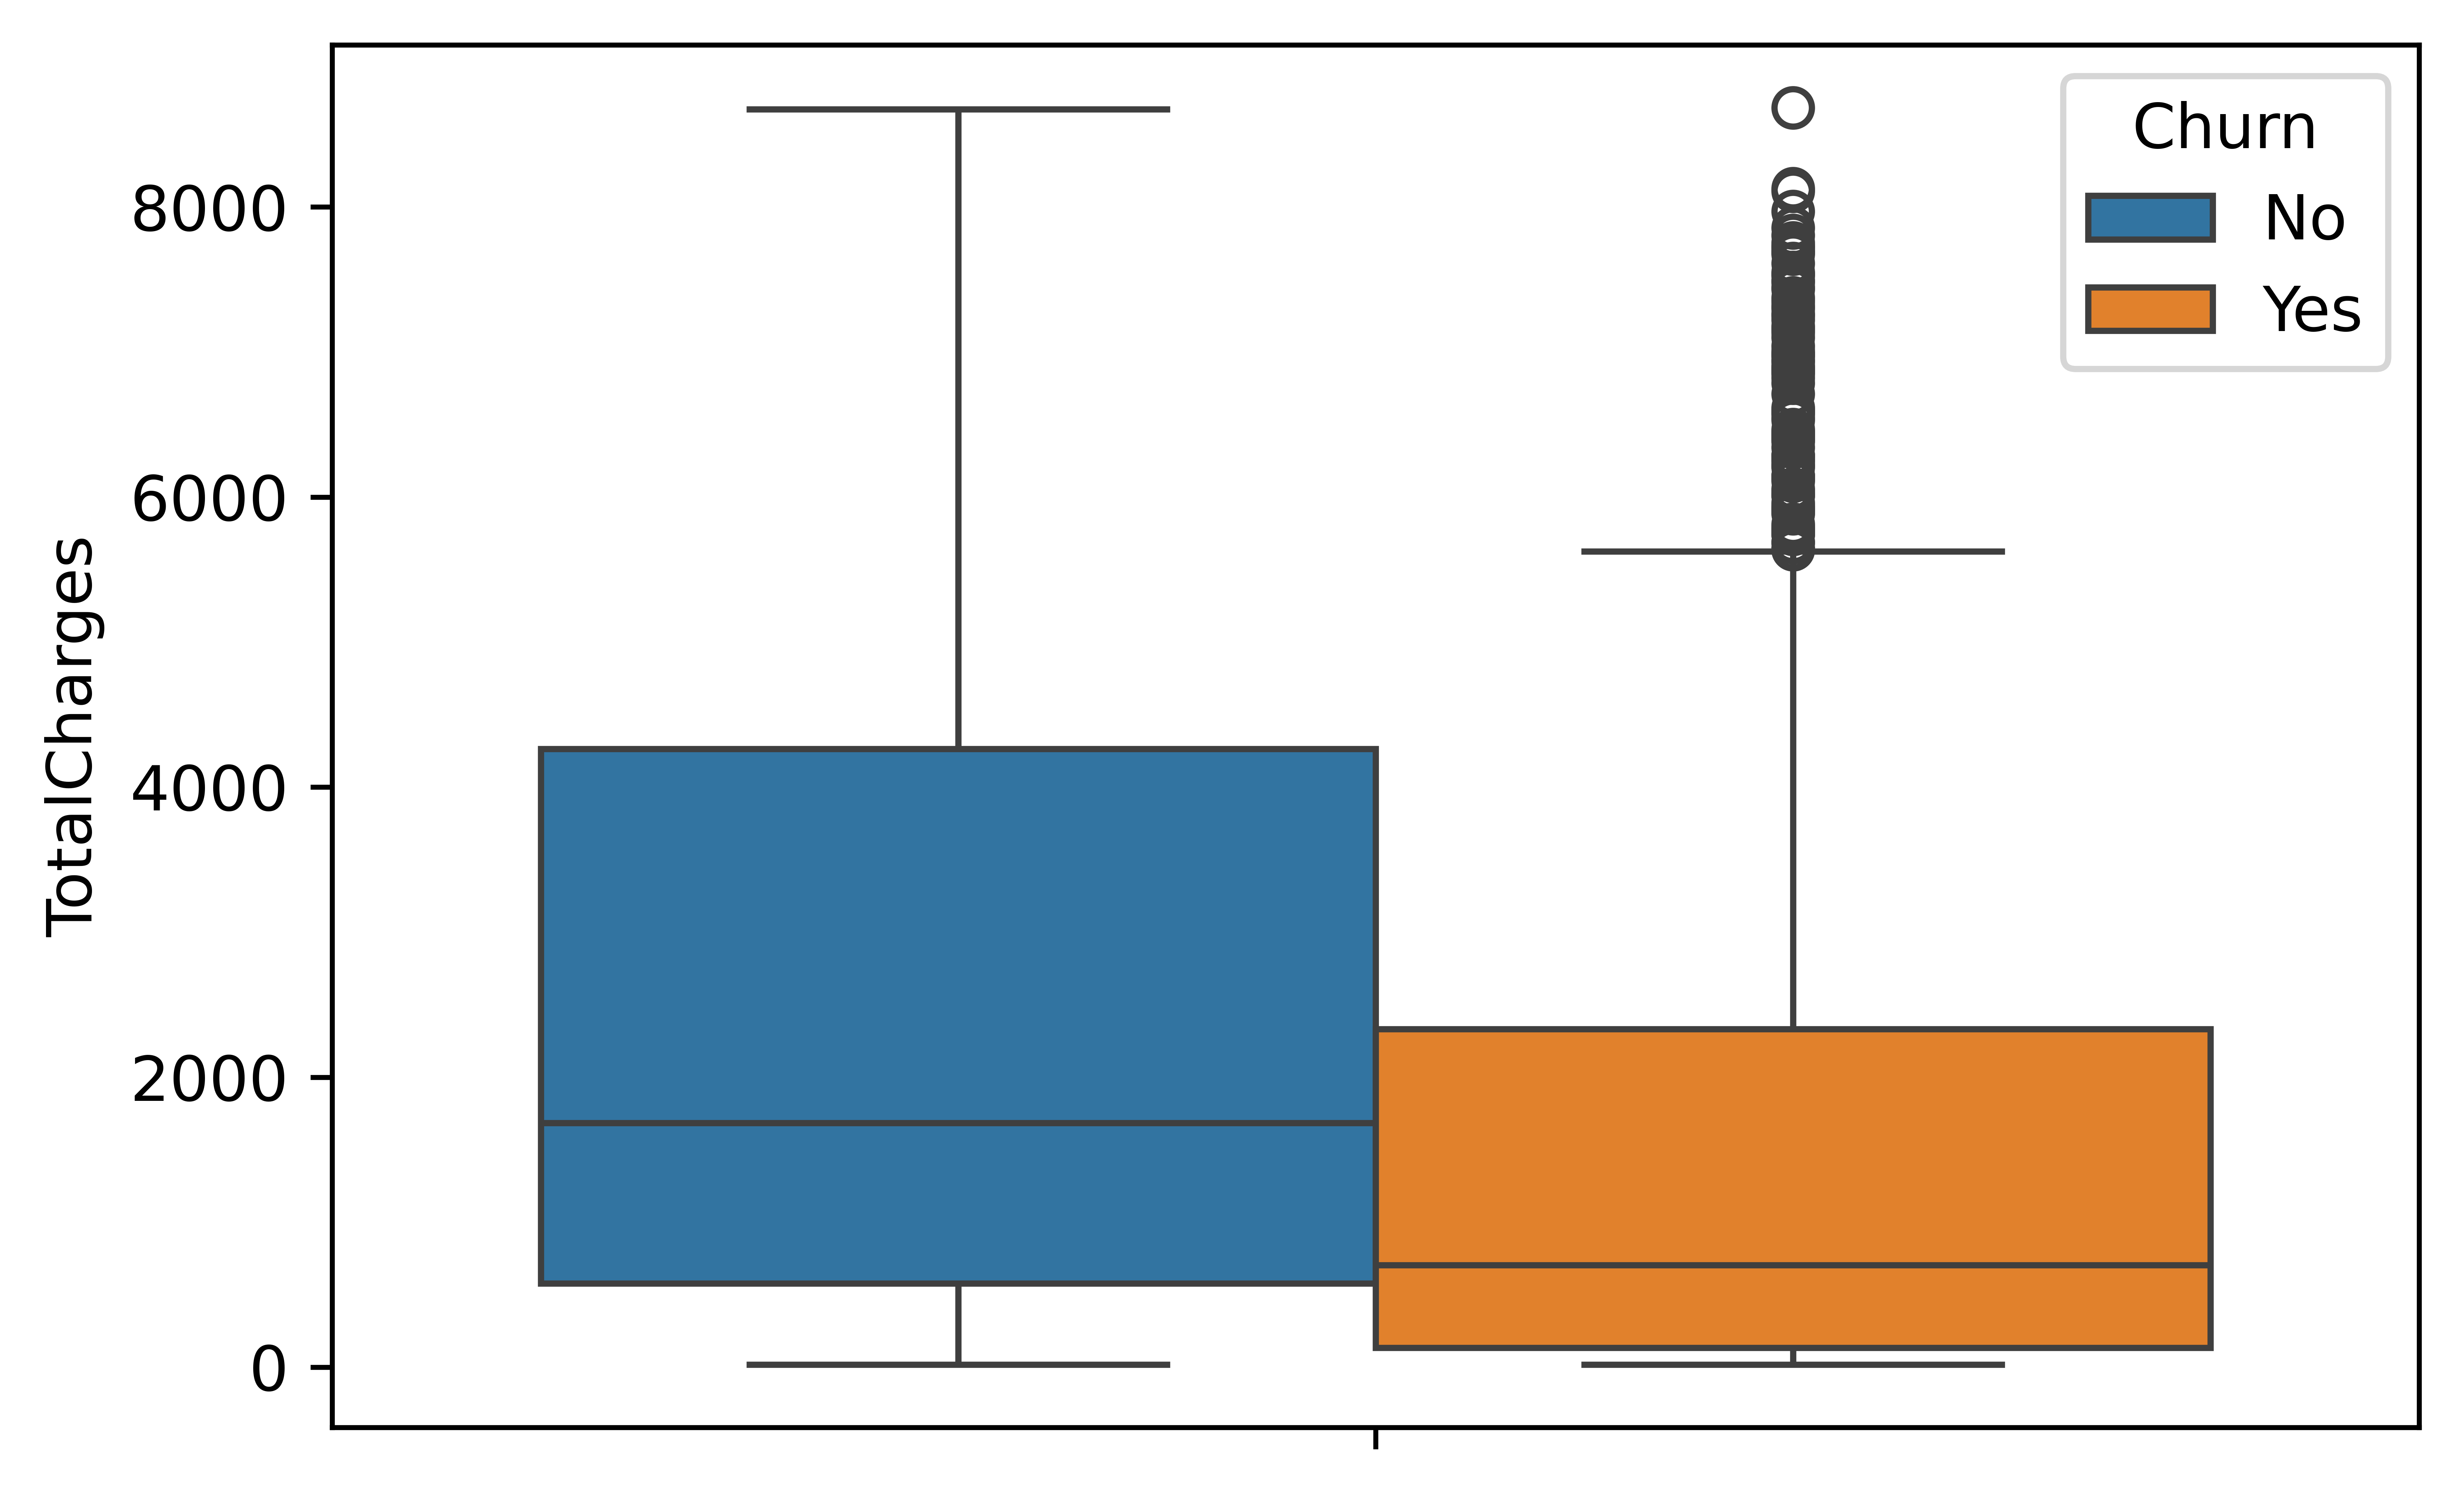

In [7]:
# Напишите Ваш код в этой ячейке
fig = plt.figure(figsize = (6, 4), dpi = 1200)
sns.boxplot(data = df, y = 'TotalCharges', hue = 'Churn')

<Axes: xlabel='Contract', ylabel='TotalCharges'>

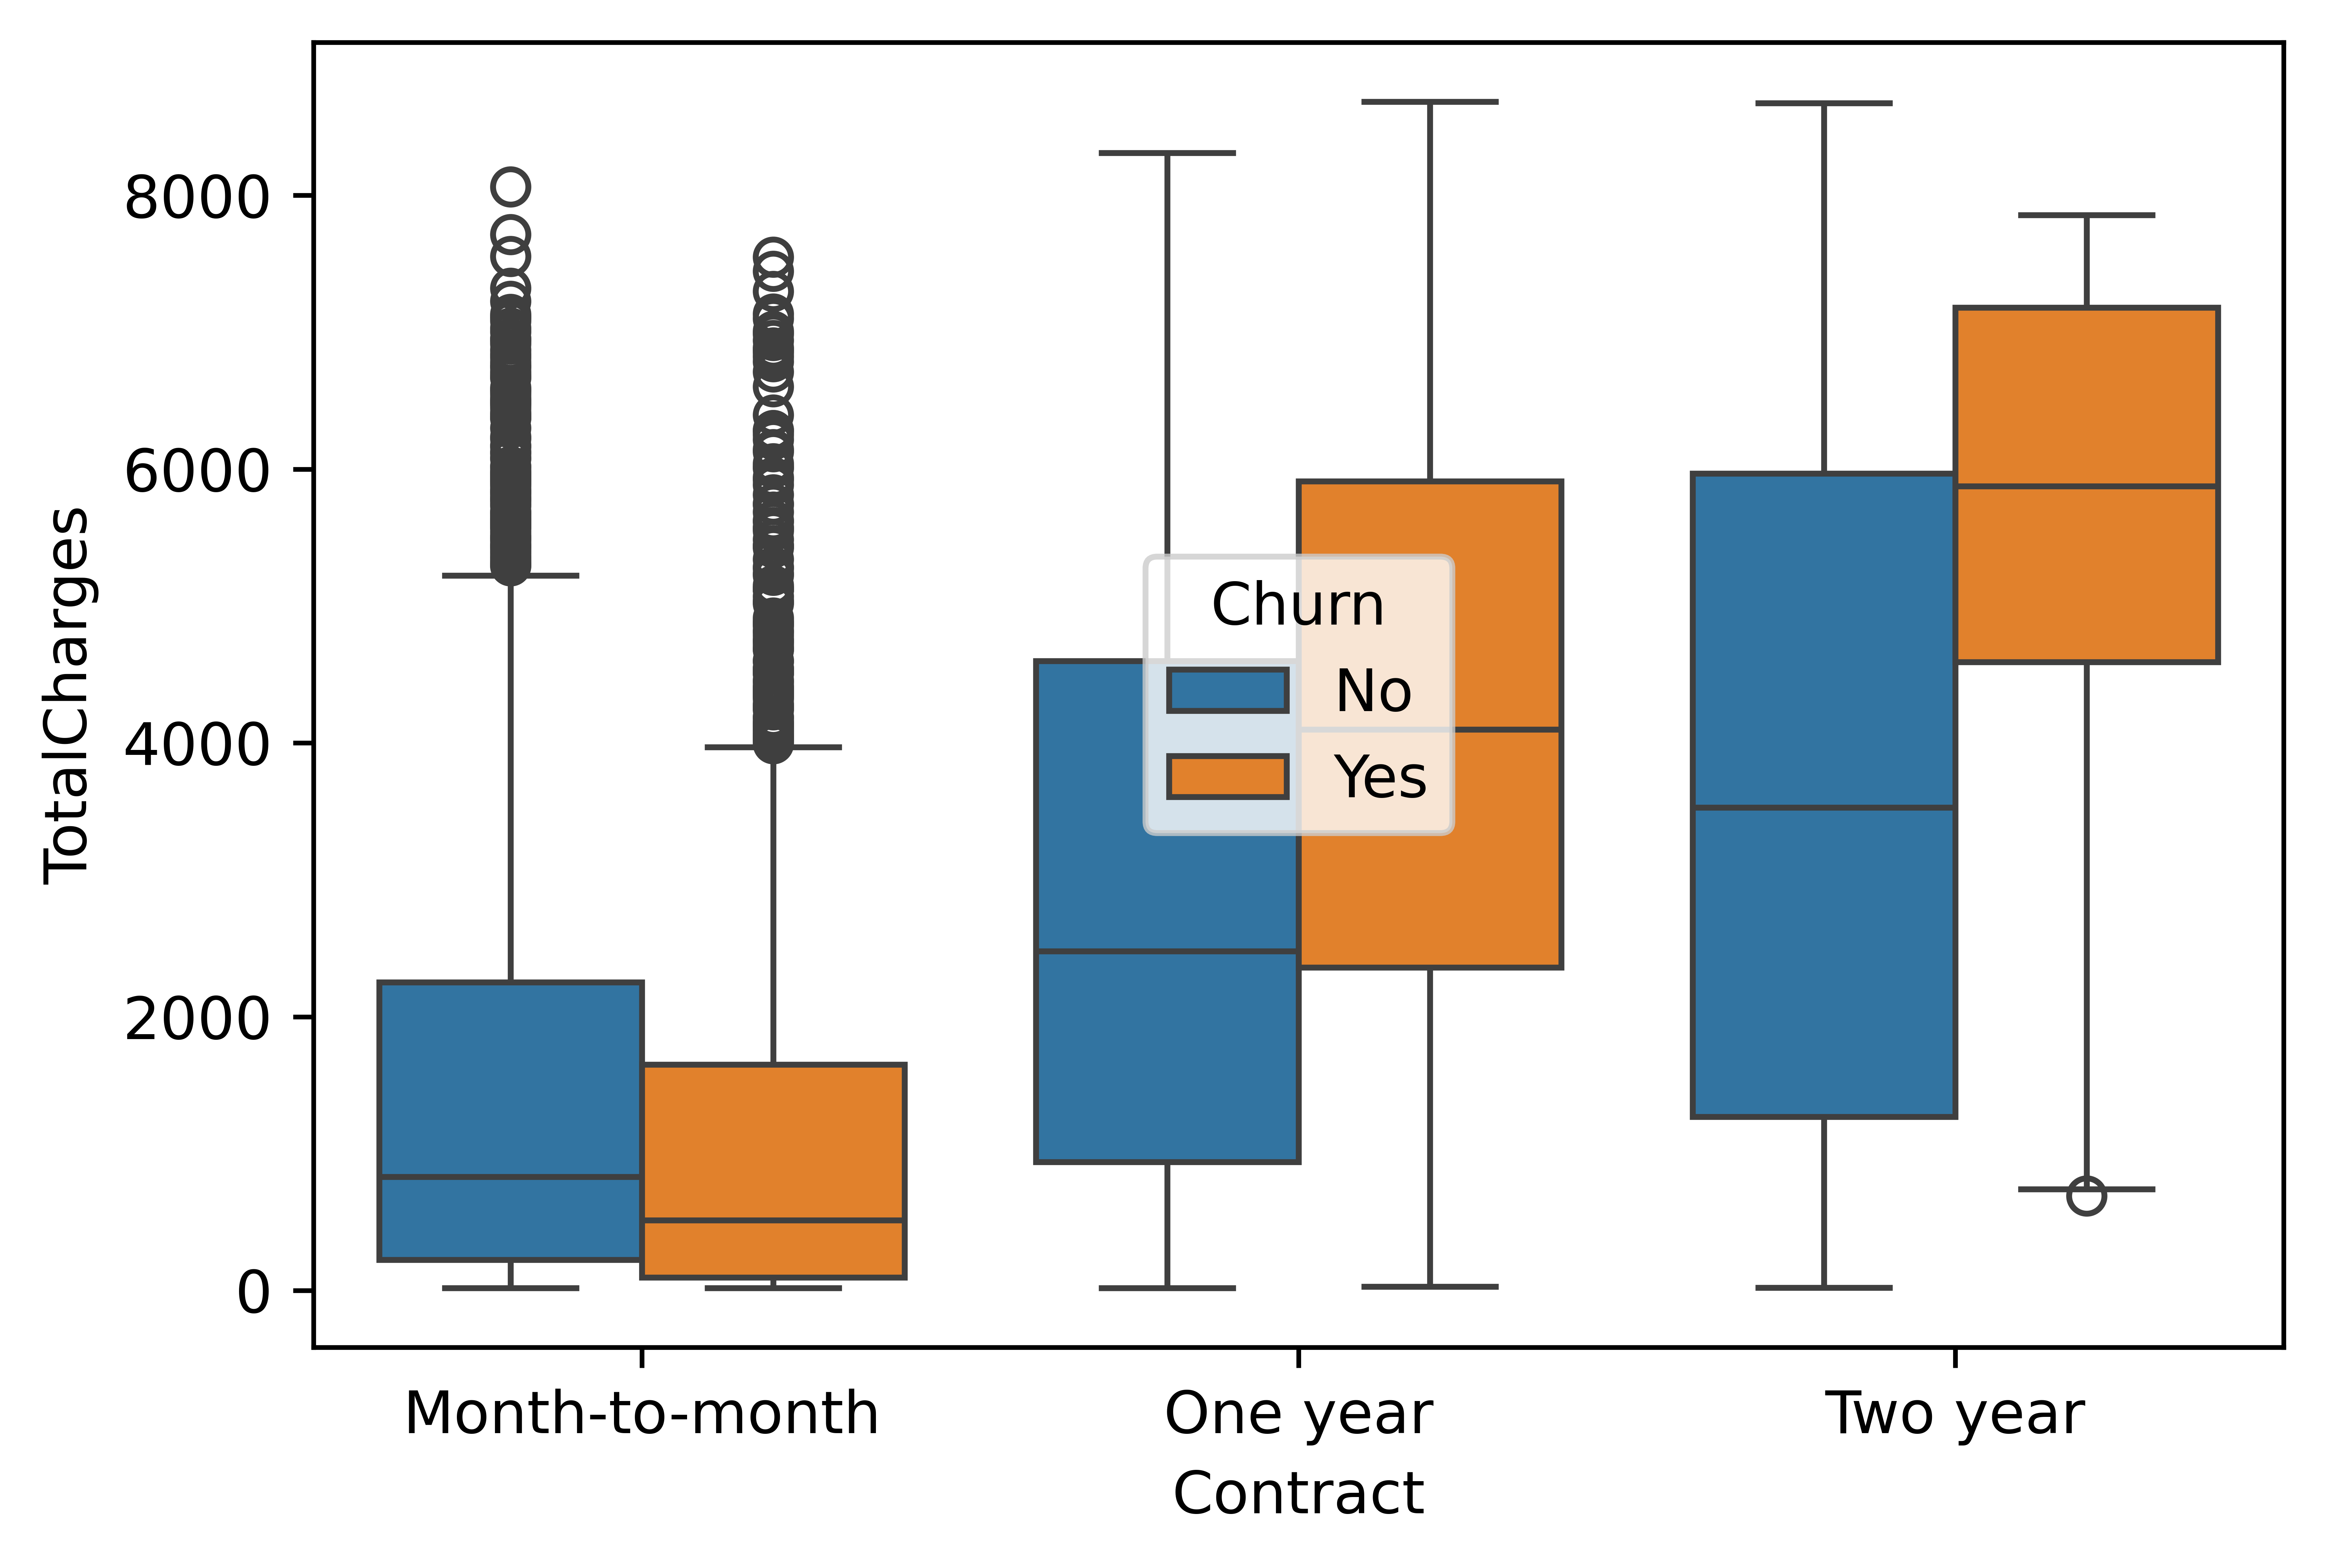

In [8]:

fig = plt.figure(figsize = (6, 4), dpi = 1200)
sns.boxplot(data = df, y = 'TotalCharges', hue = 'Churn', x = 'Contract')


<img src='fig2.png' >

**Задание: Постройте график boxplot с распределением колонки TotalCharges для различных типов контрактов, а также добавьте раскраску цветами по колонке Churn.**

<Axes: xlabel='Contract', ylabel='TotalCharges'>

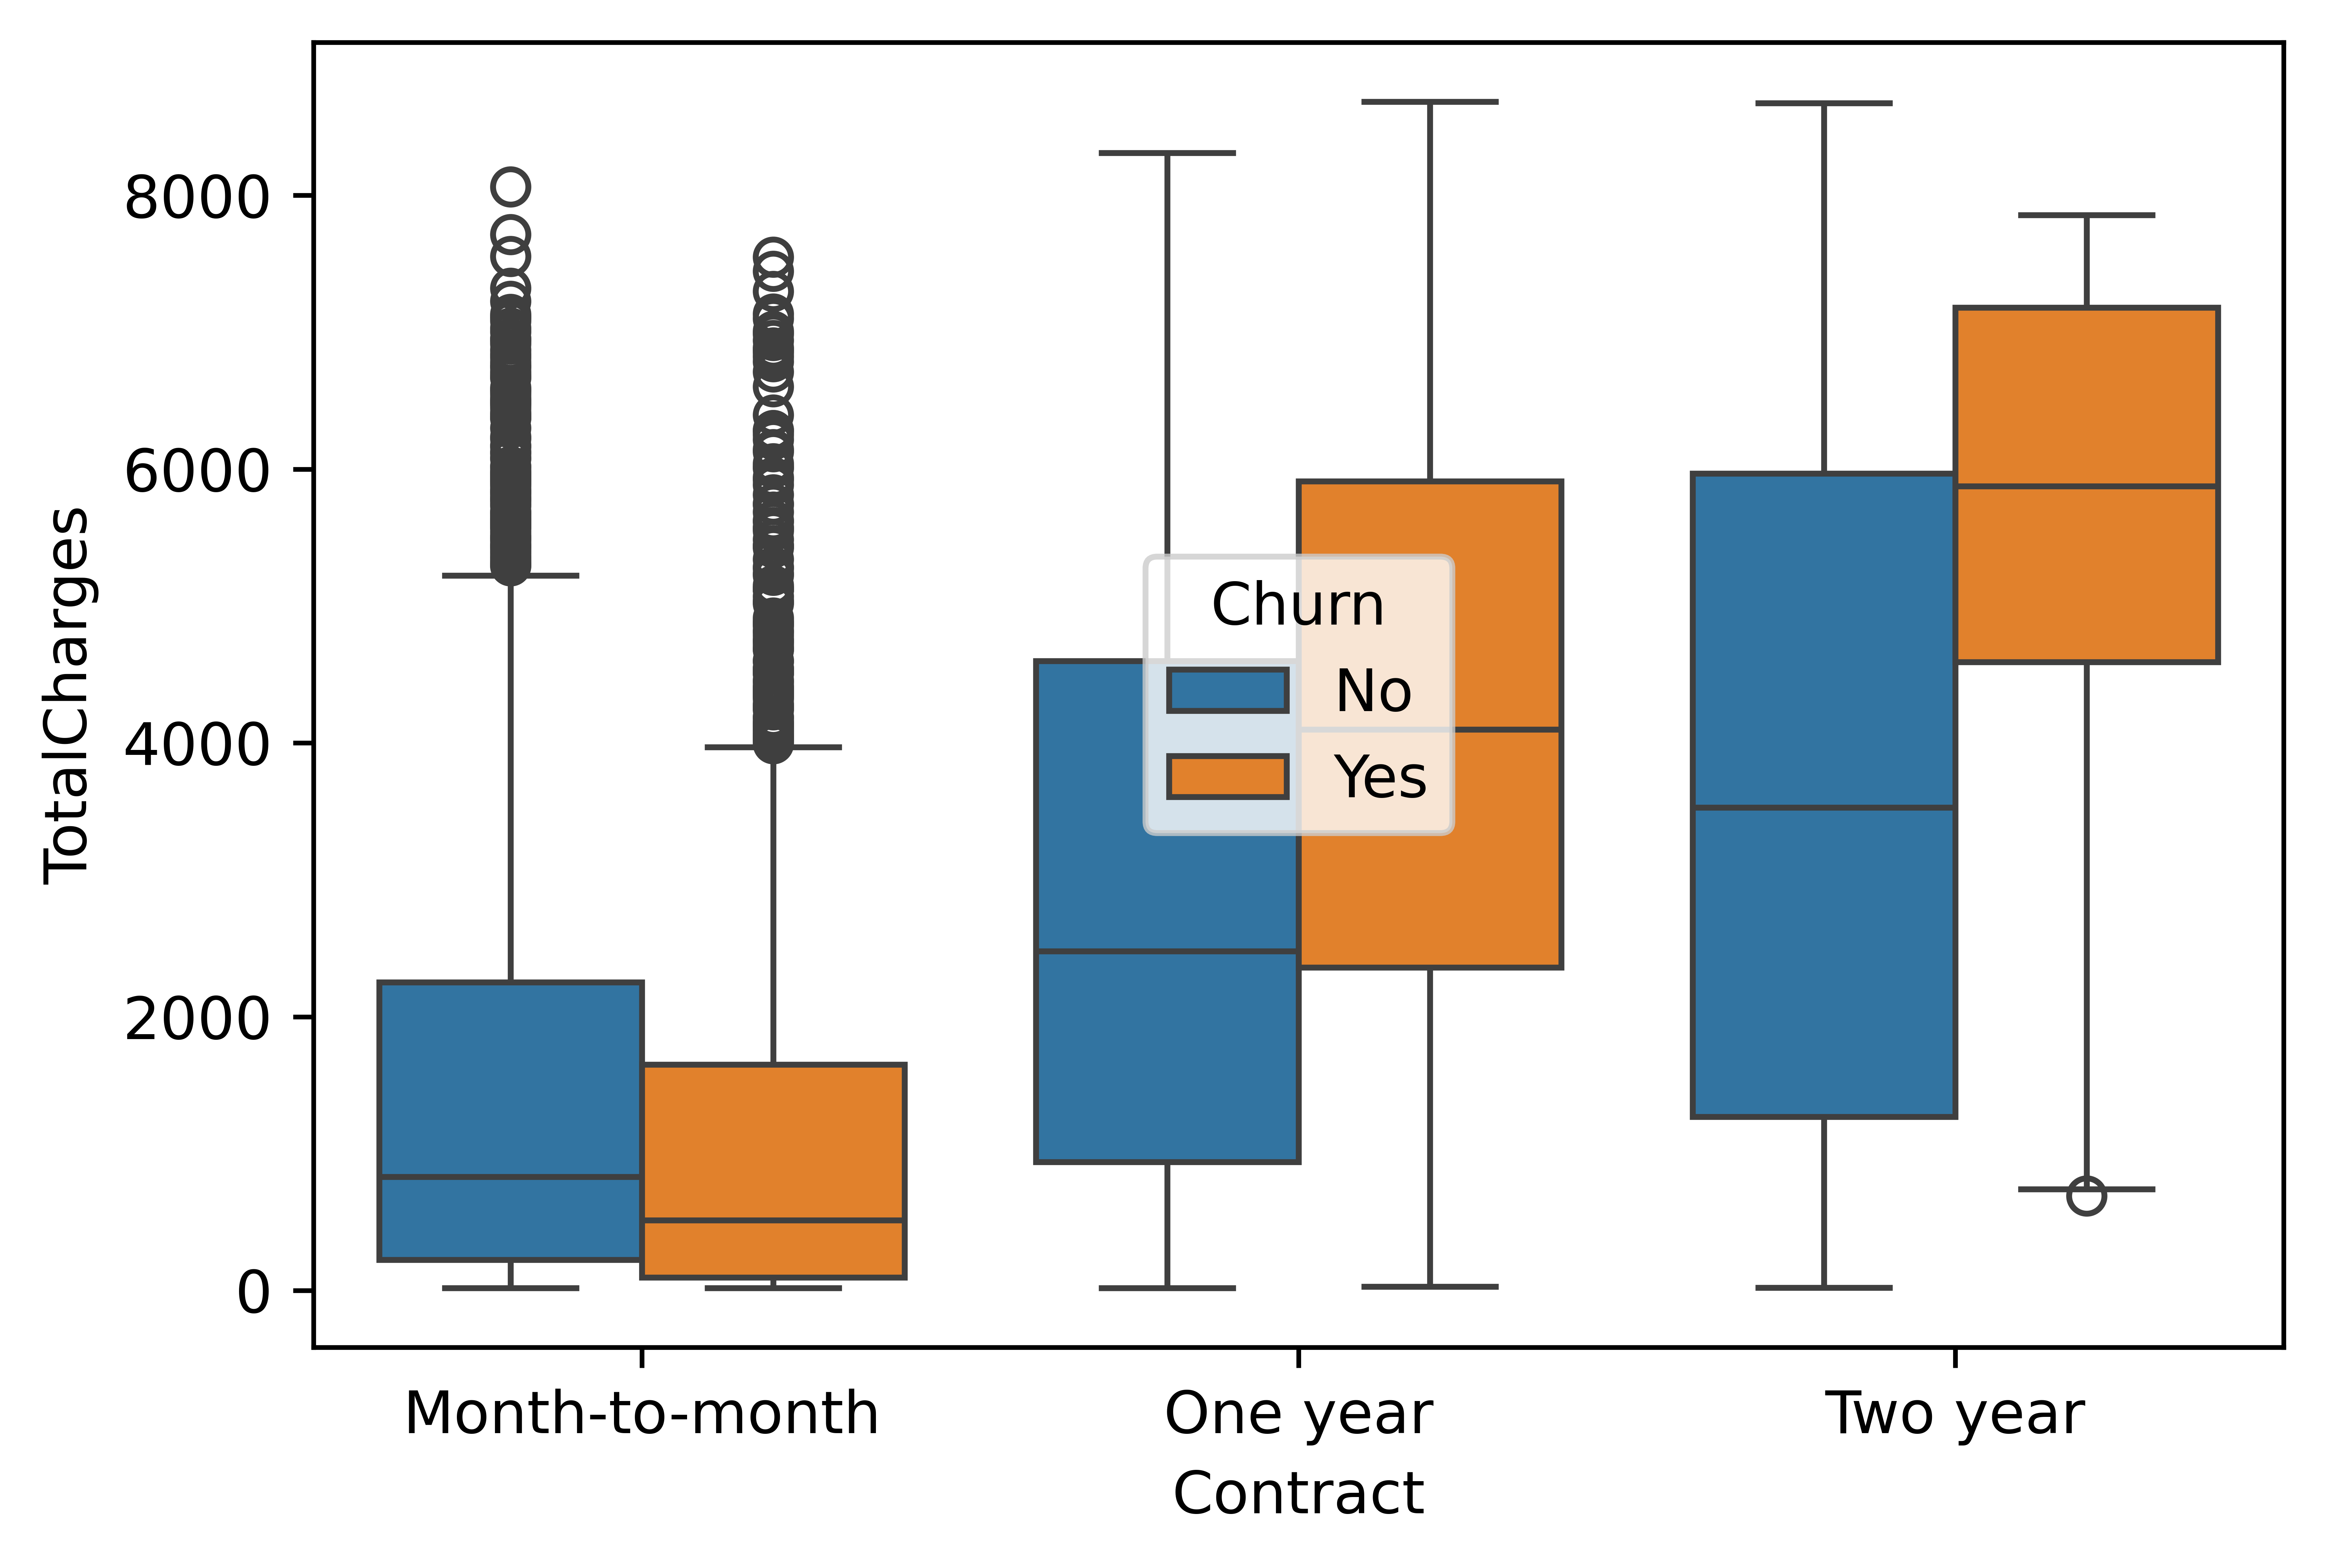

In [9]:

fig = plt.figure(figsize = (6, 4), dpi = 1200)
sns.boxplot(data = df, y = 'TotalCharges', hue = 'Churn', x = 'Contract')


<img src='fig3.png' >

**Задание: Постройте график barplot с корреляции указанных ниже признаков с целевой переменной. Обратите внимание, что для категориальных признаков сначала нужно сконвертировать их в дамми-переменные, потому что корреляция вычисляется только для числовых колонок.**

    ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
     'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

***Мы специально привели список признаков, чтобы не проверять все признаки. Дело в том, что некоторые признаки имеют слишком много уникальных значений для такого анализа, например колонка customerID.***

In [10]:
# Напишите Ваш код в этой ячейке
categorial_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents','PhoneService', 'MultipleLines', 
 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
   'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

dict_replace = {True: 1, False: 0, 'Yes': 1, 'No': 0}
# Delete extra feature after getting dummies (for ml in advance)
df_dummies = pd.get_dummies(data= df, columns= categorial_features, dtype= int, drop_first= True).replace(dict_replace)
df_dummies = df_dummies.replace(dict_replace)
df_dummies['Churn'] = df_dummies['Churn'].astype(int)
df_dummies

C:\Users\Nemat\AppData\Local\Temp\ipykernel_1228\3609117468.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dummies = pd.get_dummies(data= df, columns= categorial_features, dtype= int, drop_first= True).replace(dict_replace)


,customerID,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_1,Partner_Yes,Dependents_Yes,PhoneService_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,7590-VHVEG,1,29.85,29.85,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,1,0
1,5575-GNVDE,34,56.95,1889.50,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,1
2,3668-QPYBK,2,53.85,108.15,1,1,0,0,0,1,...,0,0,0,0,0,0,1,0,0,1
3,7795-CFOCW,45,42.30,1840.75,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,9237-HQITU,2,70.70,151.65,1,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,24,84.80,1990.50,0,1,0,1,1,1,...,0,1,0,1,1,0,1,0,0,1
7028,2234-XADUH,72,103.20,7362.90,0,0,0,1,1,1,...,0,1,0,1,1,0,1,1,0,0
7029,4801-JZAZL,11,29.60,346.45,0,0,0,1,1,0,...,0,0,0,0,0,0,1,0,1,0
7030,8361-LTMKD,4,74.40,306.60,1,1,1,1,0,1,...,0,0,0,0,0,0,1,0,0,1


C:\Users\Nemat\AppData\Local\Temp\ipykernel_1228\486197023.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = corrs.index, y = corrs.values, palette= 'coolwarm')


<Axes: xlabel='None'>

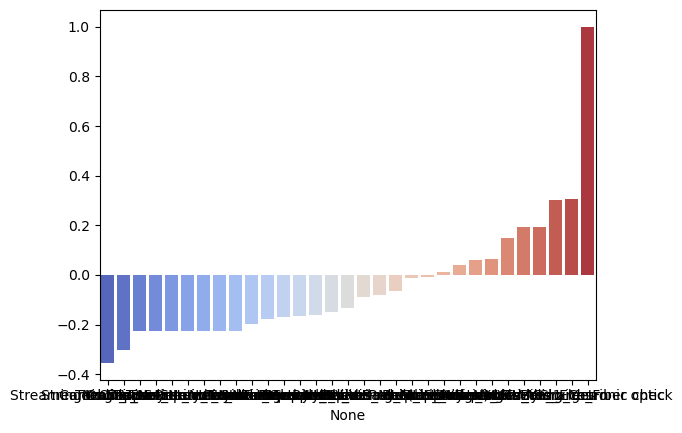

In [11]:
corrs = df_dummies.corr(numeric_only= True)['Churn'].sort_values()
sns.barplot(x = corrs.index, y = corrs.values, palette= 'coolwarm')


<img src='figbar.png'>

---
---

# Часть 3: Анализ оттока

**В этих заданиях мы выполним сегментацию абонентов на основе колонки tenure, создавая "когорты" и выполняя сравнение данных между различными когортами.**

**Задание: Перечислите 3 типа контракта (колонка Contract).**

In [12]:
# Напишите Ваш код в этой ячейке
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

**Задание: Создайте гистограмму с распределением значений колонки tenure - это количество месяцев, сколько времени человек является (или являлся) абонентом компании.**

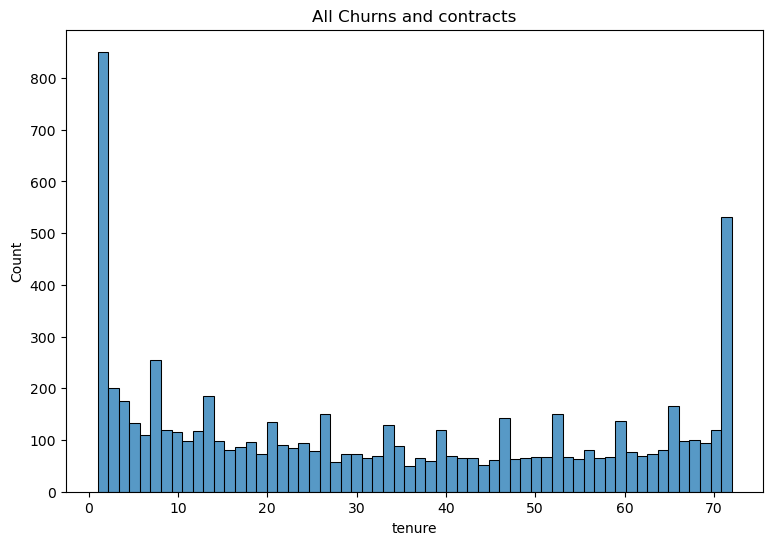

In [37]:
# Напишите Ваш код в этой ячейке
def hist_for_tenure(df, rows: int, cols: int, index: int, title = 'All Churns and contracts'):
    fig = plt.figure(figsize = (9, 6))
    axes = plt.subplot(rows, cols, index)
    sns.histplot(data = df, x = 'tenure', bins= 60)
    plt.title(title)
    
hist_for_tenure(df, 1, 1, 1)

<img src="fig5.png">

**Задание: Постройте гистограммы для колонки tenure, разбивая данные по двум колонкам - Churn и Contract. Посмотрите документацию по seaborn или блокноты для раздела про seaborn, чтобы вспомнить, как это делается.**

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

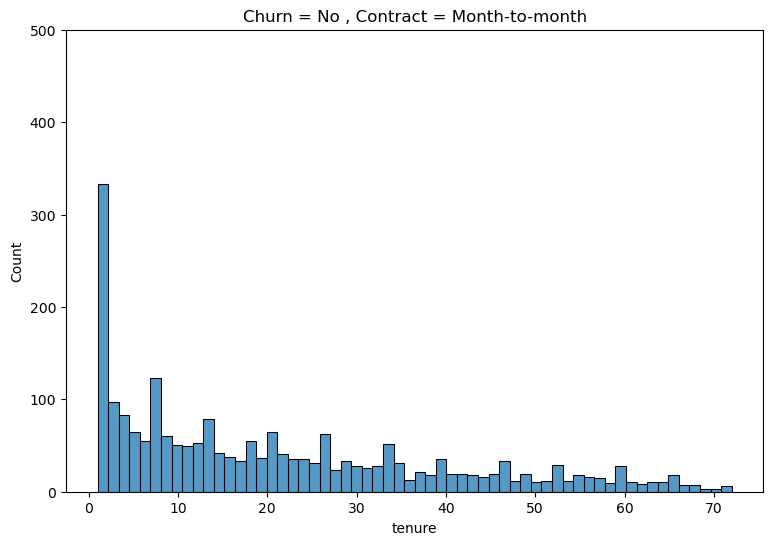

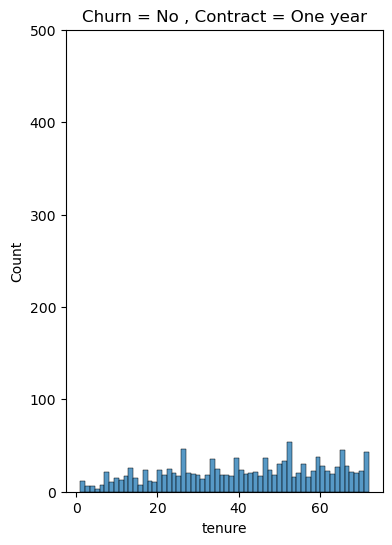

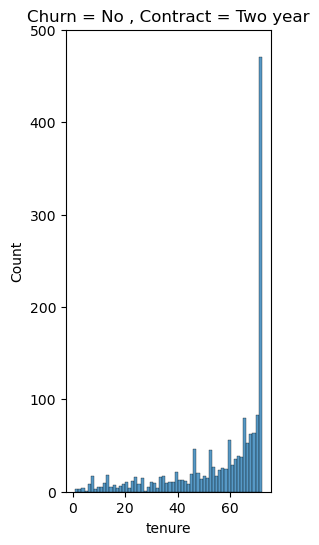

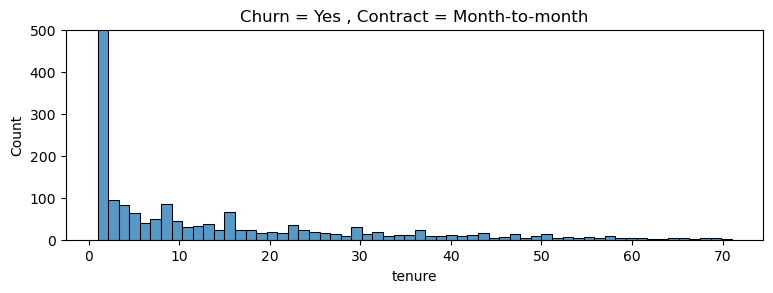

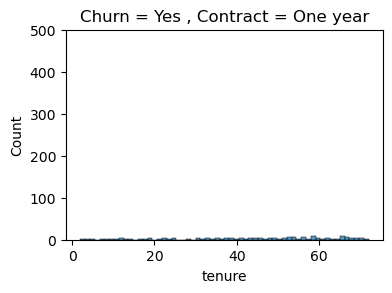

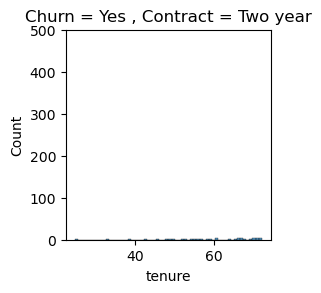

In [42]:
# Напишите Ваш код в этой ячейке
churnes = df['Churn'].unique()
contracts = df['Contract'].unique()

for i in range(2):
    for j in range (3):
        # filteres dataframe by churn and contract conditional
        df_conditional = df[(df['Churn'] == churnes[i]) & (df['Contract'] == contracts[j])]
        hist_for_tenure(df_conditional, i + 1, j + 1, 1, f'Churn = {churnes[i]} , Contract = {contracts[j]}')
        plt.ylim(0, 500)

contracts

<img src="fig6.png">

**Задание: Постройте график scatterplot для колонок Total Charges и Monthly Charges, раскрашивая график цветами по колонке Churn.**

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

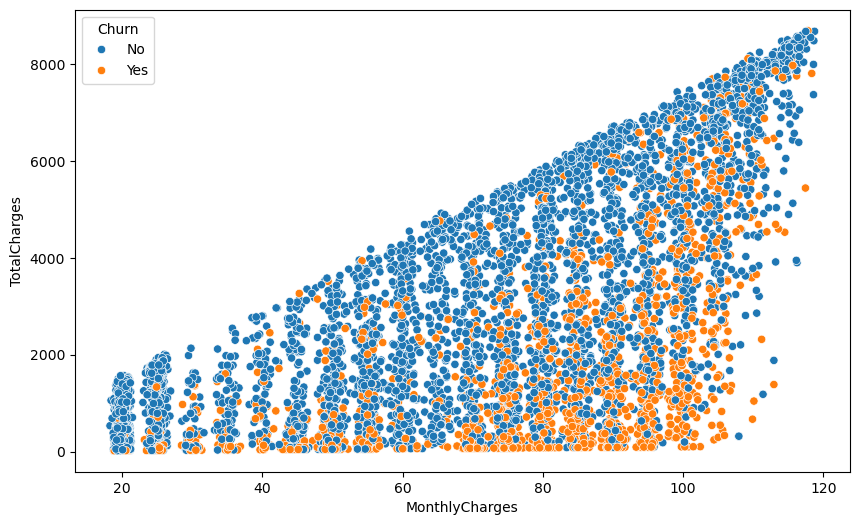

In [83]:
# Напишите Ваш код в этой ячейке
fig = plt.figure(figsize= (10, 6))
sns.scatterplot(data = df, x = 'MonthlyCharges', y = 'TotalCharges', hue = 'Churn')

<img src='fig7.png'>

### Создание когорт (сегментов) по колонке Tenure

**Для начала поместим различные значения tenure (1 месяц, 2 месяца, 3 месяца и так далее) в отдельные когорты (сегменты).**

**Задание: Для каждого уникального значения колонки tenure в качестве когорты, вычислите процент оттока (churn rate) - это количество тех людей, кто ушёл в отток в когорте, как процент от общего количества людей в данной когорте. Вычислите такой процент отдельно для каждой когорты. Например, для когорты с tenure = "1 месяц" должен получиться процент оттока 61.99%. В итоге у Вас должны получиться когорты от 1 до 72 месяцев, и с увеличением количества месяцев уровень оттока должен снижаться. Это разумно, потому что чем дольше человек пользуется услугами компании, тем вероятнее то, что его/её всё устраивает, и он/она продолжит пользоваться этими услугами.**

C:\Users\Nemat\AppData\Local\Temp\ipykernel_1228\1825192574.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_churn_rate = df.replace(dicti_replace).groupby('tenure')[['Churn']].agg({'Churn': churn_rate})


Text(0, 0.5, 'churn_percentage')

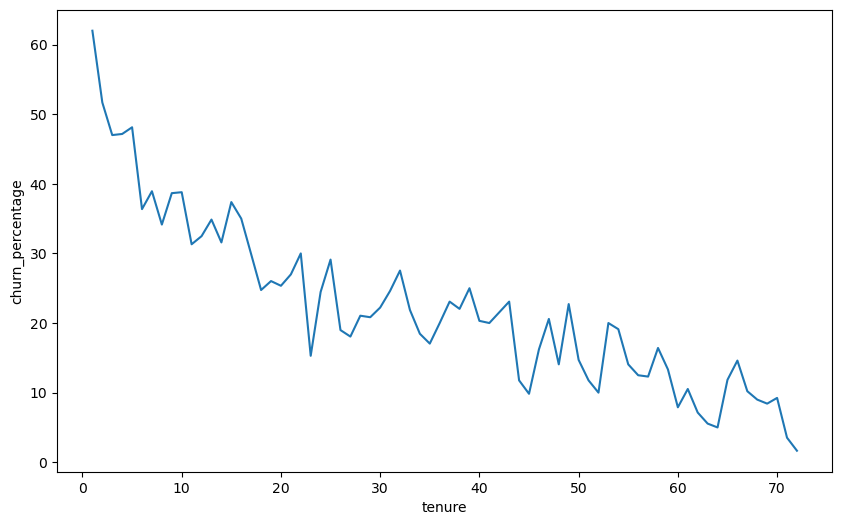

In [54]:
# Напишите Ваш код в этой ячейке
dicti_replace = {'Yes': 1, 'No': 0}
# finds percentasge of retention
def churn_rate(series):
    return sum(series) / len(series) * 100
    
df_churn_rate = df.replace(dicti_replace).groupby('tenure')[['Churn']].agg({'Churn': churn_rate})

fig = plt.figure(figsize= (10, 6))
plt.plot(df_churn_rate.index, df_churn_rate['Churn'])
df_churn_rate
plt.xlabel('tenure')
plt.ylabel('churn_percentage')

**Задание: Используя результаты предыдущего задания, постройте график процента оттока для различных значений tenure.**

In [34]:
# Напишите Ваш код в этой ячейке


<img src='fig9.png'>

### Более крупные когорты (сегменты)
**Задание: На основе колонки tenure создайте новую колонку с названием "Tenure Cohort", в которой будут следующие 4 категории:**
   * '0-12 месяцев'
   * '12-24 месяцев'
   * '24-48 месяцев'
   * 'Более 48 месяцев'    

In [55]:
# Напишите Ваш код в этой ячейке
def break_into_groups(x):
    if 0 <= x and x < 12:
        return '0-12 month'
    elif 12 <= x and x < 24:
        return '12-24 month'
    elif 24 <= x and x <= 48:
        return '24-48 month'
    elif x >= 48:
        return 'over 48 month'
        
df['tenure_cohorts'] = df['tenure'].apply(lambda x: break_into_groups(x))
df


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,tenure_cohorts
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0-12 month
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,24-48 month
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,0-12 month
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,24-48 month
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,0-12 month
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,24-48 month
7028,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,over 48 month
7029,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,0-12 month
7030,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,0-12 month


**Задание: Постройте график scatterplot для Total Charges и Monthly Charges, раскрашивая график разными цветами по колонке "Tenure Cohort", которую Вы создали в предыдущем задании.**

<Axes: xlabel='MonthlyCharges', ylabel='TotalCharges'>

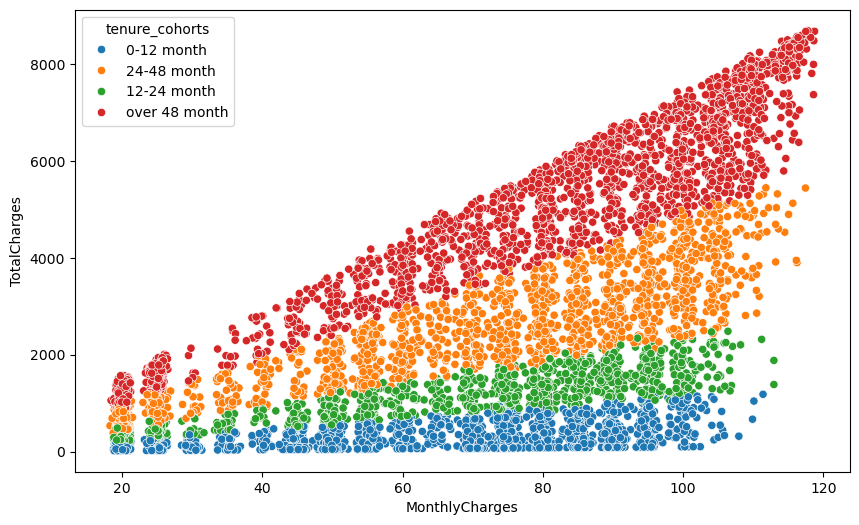

In [58]:
# Напишите Ваш код в этой ячейке
fig  = plt.figure(figsize = (10, 6))
sns.scatterplot(data = df, x = 'MonthlyCharges', y = 'TotalCharges', hue = 'tenure_cohorts')

# Можем заметить, что чем выше период пользования услугами пользователей (tenure), тем больше влияние помесячных затрат на итоговые затраты пользователей, тк по графику есть хорошая корелляция между данными признаками, коэффициент пропорциональности выше на красной полосе.
# Так что, от пользователей с высоким периодом пользования мы можем извлечь большую итговую прибыль с поднятием их помесячных затрат (надо периодически раз в месяц предлагать актуальные услуги других наших продуктов)


<img src='fig10.png'>

**Задание: Постройте график countplot с количеством ушедших и не ушедших в отток людей в каждой когорте.**

<Axes: xlabel='tenure_cohorts', ylabel='count'>

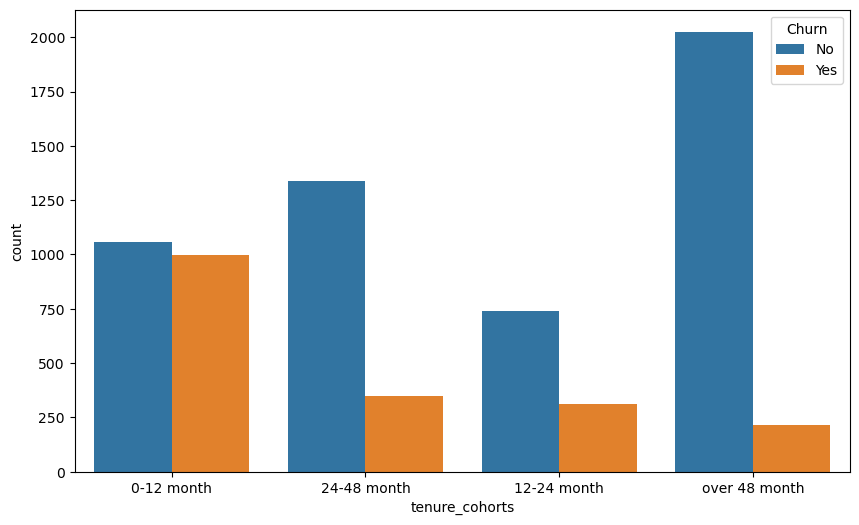

In [59]:
fig = plt.figure(figsize = (10, 6))
sns.countplot(data = df, x = 'tenure_cohorts', hue = 'Churn')

<img src='cplot.png'>

**Задание: Создайте набор графиков CountPlot с количеством людей по различным когортам Tenure Cohort. Для каждого типа контракта создайте отдельный график, и раскрасьте эти графики разными цветами по колонке Churn.**

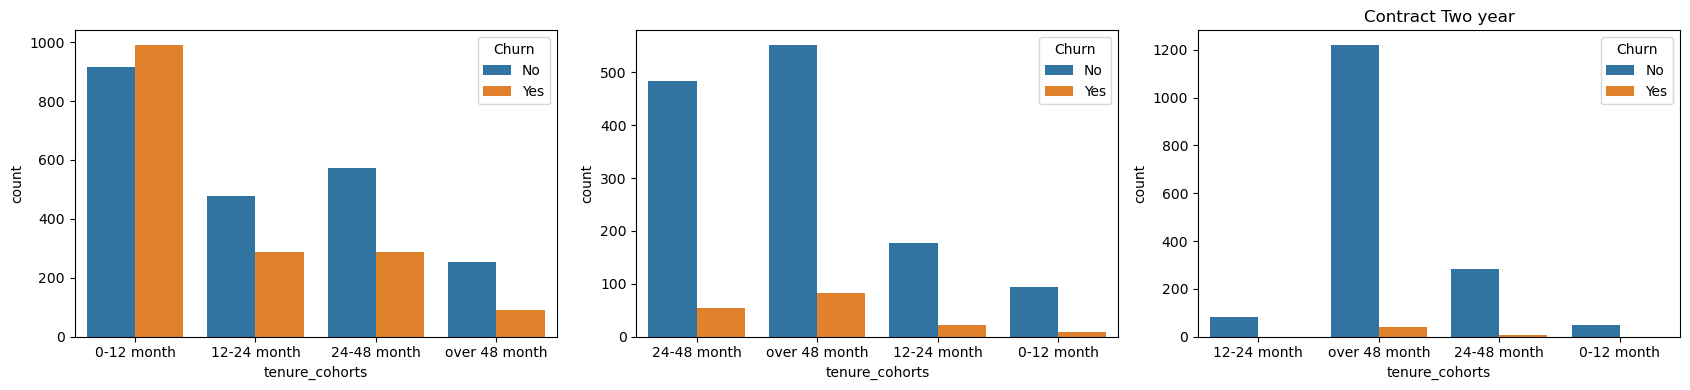

In [81]:
# Напишите Ваш код в этой ячейке
fig, axes =  plt.subplots(1, 3, figsize = (17, 4))
tenure_cohorts = df['tenure_cohorts'].unique()
contracts = df['Contract'].unique()

for i in range(3):
    df_contract = df[df['Contract'] == contracts[i]]
    sns.countplot(data = df_contract, x = 'tenure_cohorts', hue = 'Churn', ax = axes[i])
    plt.title(f'Contract {contracts[i]}')
    plt.tight_layout()

<img src='fig11.png'>

-----

# Часть 4: Предиктивная модель

**Давайте исследуем 4 модели на основе деревьев: одно дерево решений, случайный лес, адаптивный бустинг и градиентный бустинг. При желании Вы можете дополнительно попробовать любые другие модели машинного обучения с учителем (supervised learning models) и сравнить результаты!**


## Одно дерево решений (Decision Tree)

**Задание: Разделите все данные на признаки X и целевую переменную Y. Создайте дамми-переменные, где это необходимо, а также посмотрите, есть ли какие-то признаки, которые можно было бы удалить.**

In [90]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay

In [89]:
# Напишите Ваш код в этой ячейке
df = pd.get_dummies(data= df, drop_first= True, dtype= int)
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,customerID_0003-MKNFE,customerID_0004-TLHLJ,customerID_0011-IGKFF,customerID_0013-EXCHZ,customerID_0013-MHZWF,customerID_0013-SMEOE,...,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes,tenure_cohorts_12-24 month,tenure_cohorts_24-48 month,tenure_cohorts_over 48 month
0,0,1,29.85,29.85,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
1,0,34,56.95,1889.50,0,0,0,0,0,0,...,1,0,0,0,0,1,0,0,1,0
2,0,2,53.85,108.15,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,0,0
3,0,45,42.30,1840.75,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,2,70.70,151.65,0,0,0,0,0,0,...,0,0,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,0,24,84.80,1990.50,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,1,0
7028,0,72,103.20,7362.90,0,0,0,0,0,0,...,1,0,1,1,0,0,0,0,0,1
7029,0,11,29.60,346.45,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
7030,1,4,74.40,306.60,0,0,0,0,0,0,...,0,0,1,0,0,1,1,0,0,0


In [ ]:
X = df.drop('Churn_Yes', axis = 1)
y = df['Churn_Yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
model_desicion_tree = DecisionTreeClassifier()
grid = {'max_depth': list(range(5, 10)), 'min_samples_leaf': list(range(5, 100, 5)), 
        'max_features': list(range(5, len(X.columns), 2))}
gridsearch = GridSearchCV(model_desicion_tree, grid, cv = 4, scoring= 'accuracy')
gridsearch.fit(X_train, y_train)
gridsearch

**Задание: Выполните разбиение данных на обучающий и тестовый наборы (train test split), откладывая в сторону 10% данных для тестирования. В решениях мы используем random_state=101.**

In [49]:
# Напишите Ваш код в этой ячейке


**Задание: Постройте модель Decision Tree и оцените её работу. Для этого выполните следующие шаги:**
   1. Обучите модель дерева решений (при желании можете выполнить поиск по сетке для поиска оптимальных значений гиперпараметров).
   2. Оцените метрики работы модели дерева решений - для этого выведите отчёт "classification report" и нарисуйте график с матрицей ошибок (confusion matrix).
   2. Посмотрите на важности признаков для получившегося дерева решений.
   4. Опционально: Нарисуйте график получившегося дерева. Обратите внимание, что если дерево получилось очень большим и Вы не выполняли усечение дерева с помощью параметров, то вызов метода plot_tree может привести к ошибке.

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.49      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.69      0.70       704
weighted avg       0.80      0.81      0.80       704



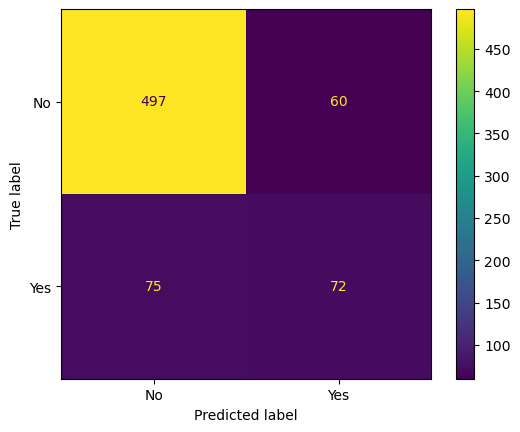

<img src='hugetree.png'>

## Случайный лес (Random Forest)

**Задание: Создайте модель случайного леса, затем выведите отчёт "classification report" и матрицу ошибок для предсказанных результатов на тестовом наборе данных.**

In [63]:
# Напишите Ваш код в этой ячейке


              precision    recall  f1-score   support

          No       0.86      0.88      0.87       557
         Yes       0.50      0.46      0.48       147

    accuracy                           0.79       704
   macro avg       0.68      0.67      0.67       704
weighted avg       0.78      0.79      0.79       704



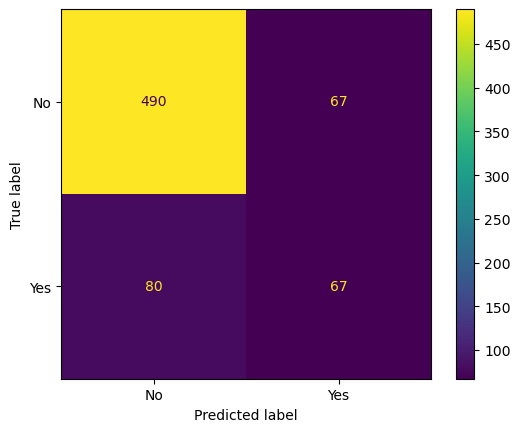

## Расширяемые деревья (Boosted Trees)

**Задание: Создайте модель AdaBoost или Gradient Boosting, затем выведите отчёт "classification report" и матрицу ошибок для предсказанных результатов на тестовом наборе данных.**

In [70]:
# Напишите Ваш код в этой ячейке


              precision    recall  f1-score   support

          No       0.88      0.90      0.89       557
         Yes       0.60      0.54      0.57       147

    accuracy                           0.83       704
   macro avg       0.74      0.72      0.73       704
weighted avg       0.82      0.83      0.83       704



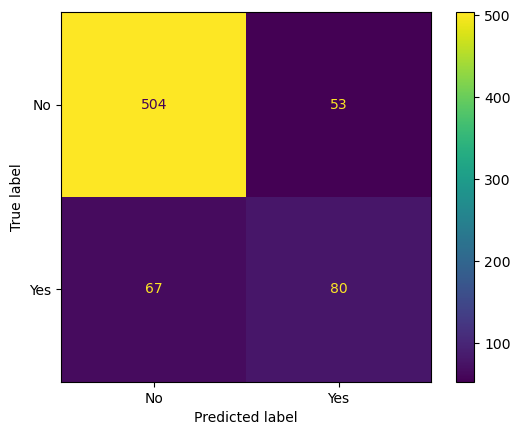

**Задания: Сравнивая результаты, какая модель у Вас работает лучше других?**

In [77]:
# У нас получились наилучшие результаты в модели AdaBoostClassifier, 
# однако надо сказать, что мы не выполняли поиск по сетке grid search,
# и целом модели показывали очень похожие результаты на этих данных.

### Отличная работа!